# 01. Análisis exploratorio del dataset - ConcertDemandAI

Este notebook contiene el análisis exploratorio de datos del proyecto **ConcertDemandAI**.

El objetivo de este archivo es revisar, describir y validar el dataset actualizado antes de pasar al entrenamiento del modelo.

En esta versión se analiza el dataset con las nuevas variables agregadas:

- `country`
- `previous_attendance_rate`
- `pre_sale_interest`
- `artist_market_score`
- `is_weekend`
- `marketing_per_capacity`
- `price_per_capacity`
- `popularity_marketing`

> Este notebook **no entrena modelos**. El entrenamiento se trabaja en un notebook separado o en `model/train.py`.


## 1. Configuración del entorno

Esta celda permite ejecutar el notebook en Google Colab. Si el repositorio no existe en `/content`, se clona automáticamente desde GitHub.


In [1]:
from pathlib import Path
import os

REPO_URL = "https://github.com/leonciochiunti/concert-demand-ml.git"
REPO_DIR = Path("/content/concert-demand-ml")

if Path("/content").exists():
    if not REPO_DIR.exists():
        !git clone {REPO_URL} {REPO_DIR}
    %cd /content/concert-demand-ml
    !git pull origin main
else:
    print("Entorno local detectado")
    print("Carpeta actual:", Path.cwd())

print("Carpeta de trabajo:", Path.cwd())
print("Archivos/carpetas disponibles:")
print(os.listdir())

Cloning into '/content/concert-demand-ml'...
remote: Enumerating objects: 44, done.
remote: Counting objects: 100% (44/44), done.
remote: Compressing objects: 100% (30/30), done.
remote: Total 44 (delta 10), reused 32 (delta 5), pack-reused 0 (from 0)
Receiving objects: 100% (44/44), 118.23 KiB | 5.37 MiB/s, done.
Resolving deltas: 100% (10/10), done.
/content/concert-demand-ml
From https://github.com/leonciochiunti/concert-demand-ml
 * branch            main       -> FETCH_HEAD
Already up to date.
Carpeta de trabajo: /content/concert-demand-ml
Archivos/carpetas disponibles:
['requirements.txt', 'app', 'data', 'notebooks', 'model', 'README.md', '.git', '.gitignore', 'reports']


## 2. Importación de librerías

In [2]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## 3. Carga del dataset

Se carga el archivo `data/dataset.csv`, el cual contiene información de conciertos y variables utilizadas para analizar la demanda esperada.


In [3]:
DATA_PATH = Path("data/dataset.csv")

df = pd.read_csv(DATA_PATH)

print("Dataset cargado correctamente")
print("Filas y columnas:", df.shape)

df.head()

Dataset cargado correctamente
Filas y columnas: (1200, 22)


,artist,genre,city,country,venue_type,capacity,month,event_day,days_until_event,marketing_budget,...,previous_attendance_rate,pre_sale_interest,artist_market_score,is_weekend,marketing_per_capacity,price_per_capacity,popularity_marketing,occupancy_pct,tickets_sold,demand_class
0,David Guetta,electronica,Los Angeles,Estados Unidos,theater,7078,5,Thursday,2,157082,...,0.82,4197,0.95,0,22.192992,4.699350,14608626,0.64,4530,media
1,Grupo Firme,banda,Bogota,Colombia,club,1791,12,Wednesday,27,51833,...,0.78,1193,0.88,0,28.940815,0.968174,4664970,0.54,967,baja
2,The Weeknd,pop,Queretaro,Mexico,theater,8188,10,Thursday,172,227767,...,0.90,5682,0.82,0,27.817171,0.504275,21865632,0.72,5895,media
3,Peso Pluma,regional_mexicano,Queretaro,Mexico,stadium,38238,11,Friday,76,471399,...,0.58,15550,0.82,1,12.328024,0.043909,43840107,0.69,26384,media
4,Ariana Grande,pop,Guadalajara,Mexico,theater,4786,6,Wednesday,48,73054,...,0.88,2651,0.92,0,15.264104,0.662975,6940130,0.59,2824,media


## 4. Estructura general del dataset

Se revisan las columnas, tipos de datos y primeras características generales del dataset.


In [4]:
print("Columnas del dataset:")
print(df.columns.tolist())

print("\nInformación general:")
df.info()

Columnas del dataset:
['artist', 'genre', 'city', 'country', 'venue_type', 'capacity', 'month', 'event_day', 'days_until_event', 'marketing_budget', 'ticket_price', 'artist_popularity', 'previous_attendance_rate', 'pre_sale_interest', 'artist_market_score', 'is_weekend', 'marketing_per_capacity', 'price_per_capacity', 'popularity_marketing', 'occupancy_pct', 'tickets_sold', 'demand_class']

Información general:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 22 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   artist                    1200 non-null   object 
 1   genre                     1200 non-null   object 
 2   city                      1200 non-null   object 
 3   country                   1200 non-null   object 
 4   venue_type                1200 non-null   object 
 5   capacity                  1200 non-null   int64  
 6   month                     1200 no

## 5. Validación de columnas esperadas

Se valida que el dataset contenga las columnas necesarias para el análisis y para el futuro entrenamiento del modelo.


In [5]:
required_columns = [
    "artist",
    "genre",
    "city",
    "country",
    "venue_type",
    "capacity",
    "month",
    "event_day",
    "days_until_event",
    "marketing_budget",
    "ticket_price",
    "artist_popularity",
    "previous_attendance_rate",
    "pre_sale_interest",
    "artist_market_score",
    "is_weekend",
    "marketing_per_capacity",
    "price_per_capacity",
    "popularity_marketing",
    "occupancy_pct",
    "tickets_sold",
    "demand_class",
]

missing_columns = [col for col in required_columns if col not in df.columns]

if missing_columns:
    print("Faltan columnas:")
    print(missing_columns)
else:
    print("Todas las columnas esperadas están presentes.")

Todas las columnas esperadas están presentes.


## 6. Valores nulos y duplicados

Se revisa si existen valores faltantes o registros duplicados.


In [6]:
print("Valores nulos por columna:")
print(df.isnull().sum())

print("\nRegistros duplicados:")
print(df.duplicated().sum())

Valores nulos por columna:
artist                      0
genre                       0
city                        0
country                     0
venue_type                  0
capacity                    0
month                       0
event_day                   0
days_until_event            0
marketing_budget            0
ticket_price                0
artist_popularity           0
previous_attendance_rate    0
pre_sale_interest           0
artist_market_score         0
is_weekend                  0
marketing_per_capacity      0
price_per_capacity          0
popularity_marketing        0
occupancy_pct               0
tickets_sold                0
demand_class                0
dtype: int64

Registros duplicados:
0


## 7. Distribución de la variable objetivo

La variable objetivo es `demand_class`, con tres categorías:

- `baja`
- `media`
- `alta`

Esta variable será utilizada posteriormente para entrenar el modelo de clasificación.


Distribución de demand_class:
demand_class
media    400
baja     400
alta     400
Name: count, dtype: int64

Distribución porcentual:
demand_class
media    33.333333
baja     33.333333
alta     33.333333
Name: proportion, dtype: float64


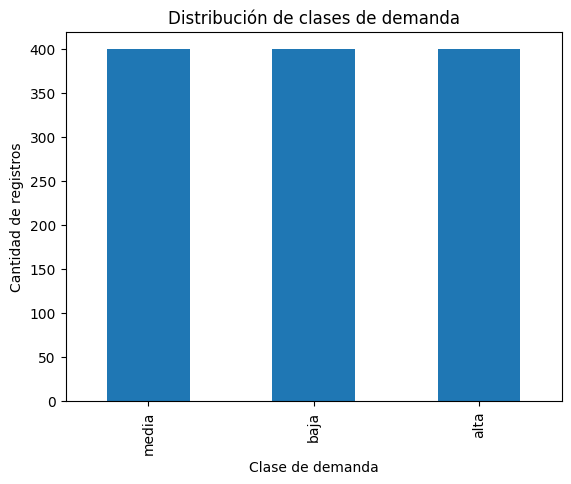

In [7]:
print("Distribución de demand_class:")
print(df["demand_class"].value_counts())

print("\nDistribución porcentual:")
print(df["demand_class"].value_counts(normalize=True) * 100)

df["demand_class"].value_counts().plot(kind="bar")
plt.title("Distribución de clases de demanda")
plt.xlabel("Clase de demanda")
plt.ylabel("Cantidad de registros")
plt.show()

## 8. Análisis de variables numéricas

Se analizan variables numéricas relacionadas con capacidad, precio, marketing, popularidad, historial previo, interés de preventa y resultados del evento.

Las columnas `occupancy_pct` y `tickets_sold` se usan únicamente para análisis, no para entrenamiento, porque representan información posterior al concierto.


In [8]:
numeric_columns = [
    "capacity",
    "month",
    "days_until_event",
    "marketing_budget",
    "ticket_price",
    "artist_popularity",
    "previous_attendance_rate",
    "pre_sale_interest",
    "artist_market_score",
    "is_weekend",
    "marketing_per_capacity",
    "price_per_capacity",
    "popularity_marketing",
    "occupancy_pct",
    "tickets_sold",
]

df[numeric_columns].describe()

,capacity,month,days_until_event,marketing_budget,ticket_price,artist_popularity,previous_attendance_rate,pre_sale_interest,artist_market_score,is_weekend,marketing_per_capacity,price_per_capacity,popularity_marketing,occupancy_pct,tickets_sold
count,1200.000000,1200.000000,1200.000000,1.200000e+03,1200.00000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1.200000e+03,1200.000000,1200.000000
mean,29008.598333,6.376667,90.755833,5.799846e+05,6113.63000,91.710833,0.731417,15063.471667,0.887208,0.298333,20.021793,1.271171,5.325300e+07,0.649958,22788.545000
std,28171.684219,3.519248,51.938546,6.089910e+05,9028.64721,4.760368,0.073816,15142.103831,0.068655,0.457717,5.774038,4.424786,5.611326e+07,0.208139,25045.017997
min,513.000000,1.000000,1.000000,5.580000e+03,1236.00000,78.000000,0.580000,207.000000,0.780000,0.000000,10.020234,0.014889,5.245200e+05,0.250000,133.000000
25%,4822.750000,3.000000,46.000000,8.529600e+04,2292.75000,90.000000,0.700000,2428.500000,0.820000,0.000000,14.962244,0.064233,7.867906e+06,0.480000,2194.250000
50%,17650.500000,6.000000,92.000000,3.413065e+05,3144.00000,93.000000,0.700000,9135.000000,0.900000,0.000000,20.126303,0.218809,3.168742e+07,0.670000,11343.500000
75%,51276.500000,9.000000,135.000000,9.284100e+05,4054.25000,95.000000,0.700000,25531.000000,0.920000,1.000000,25.106602,0.849792,8.485853e+07,0.840000,41474.000000
max,99064.000000,12.000000,180.000000,2.849841e+06,39919.00000,99.000000,0.950000,66549.000000,1.000000,1.000000,29.986871,71.241843,2.650352e+08,0.970000,92886.000000


## 9. Histogramas de variables numéricas

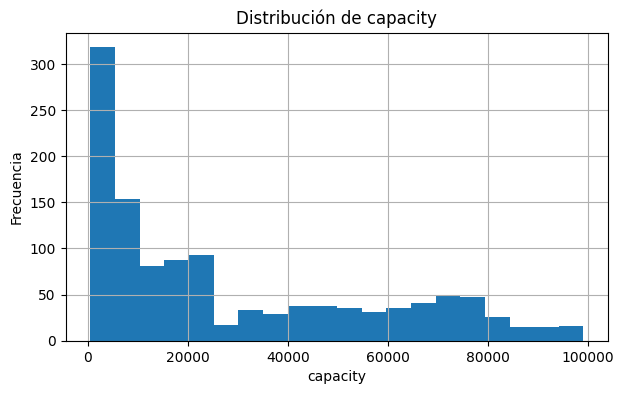

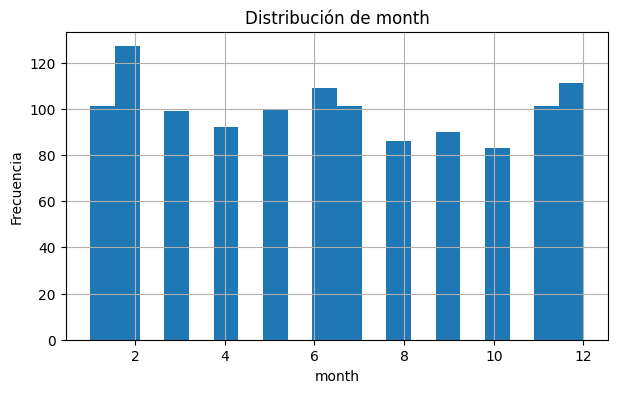

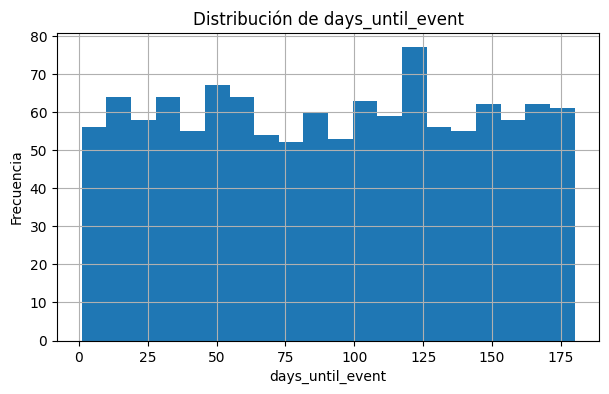

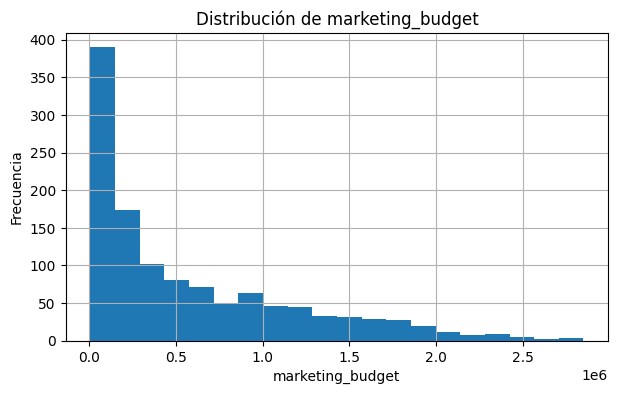

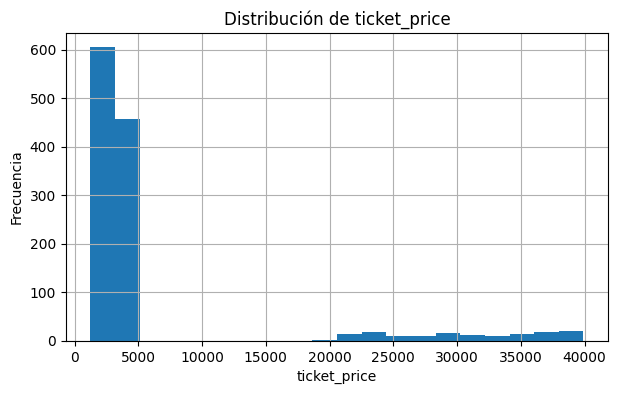

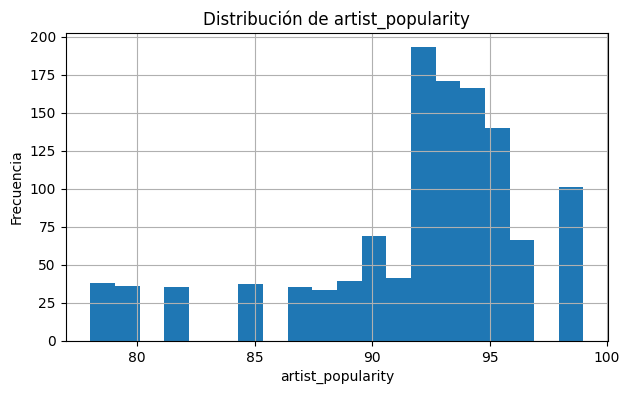

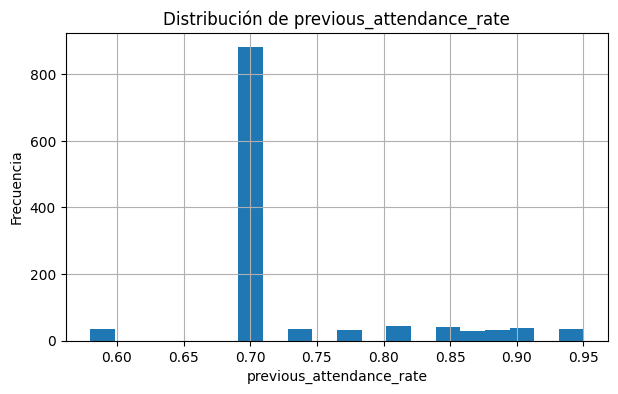

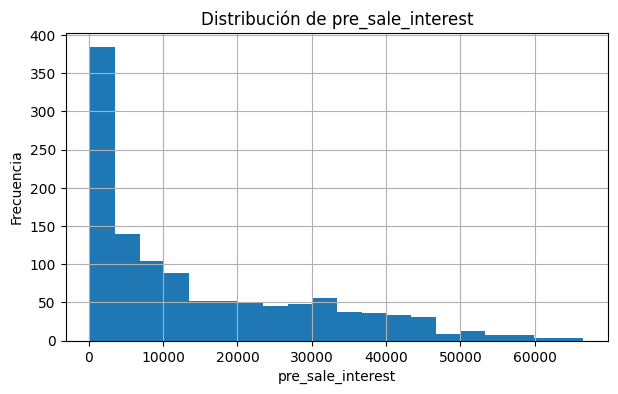

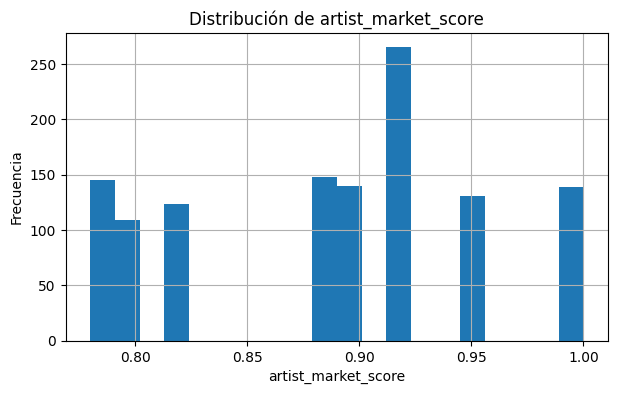

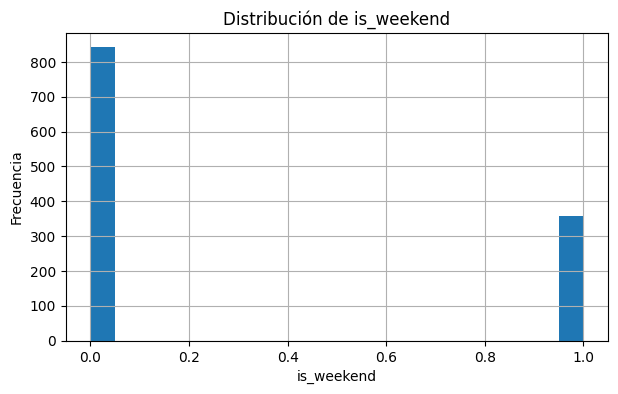

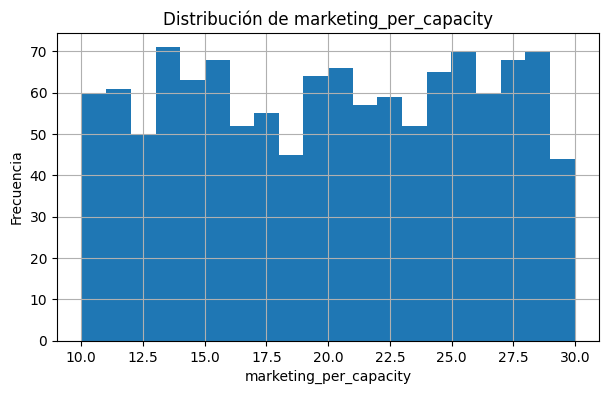

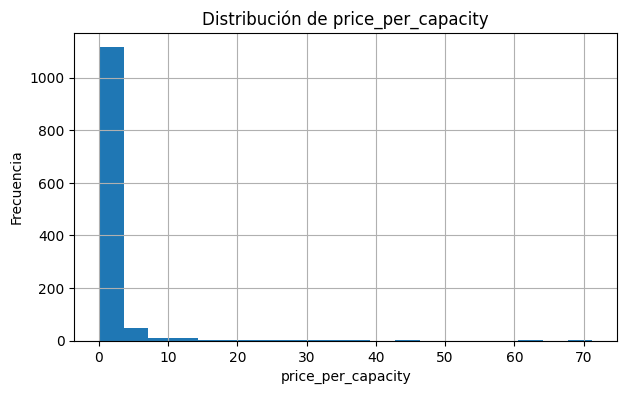

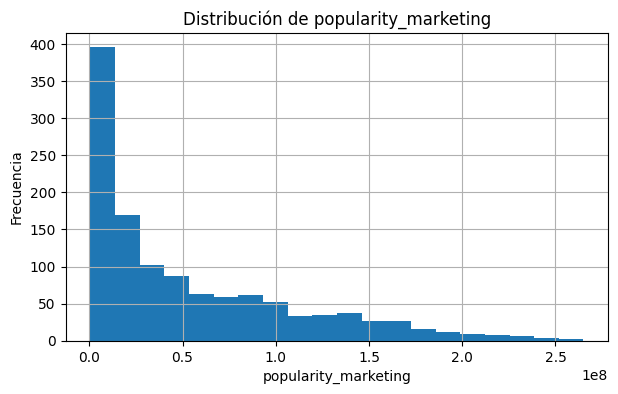

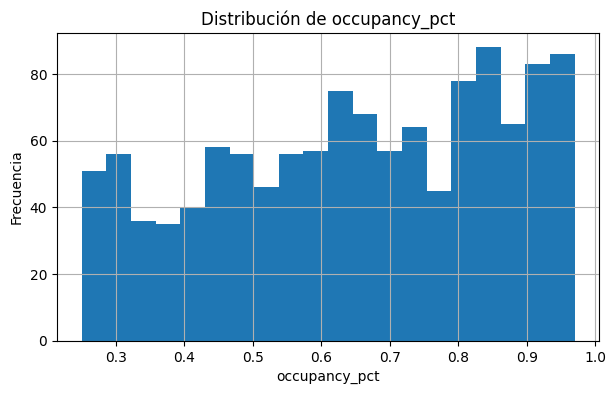

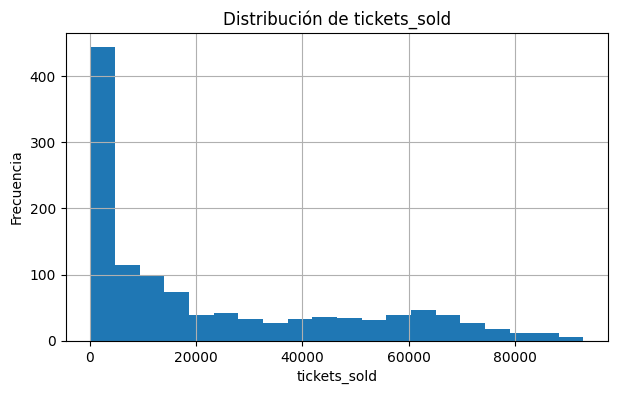

In [9]:
for col in numeric_columns:
    plt.figure(figsize=(7, 4))
    df[col].hist(bins=20)
    plt.title(f"Distribución de {col}")
    plt.xlabel(col)
    plt.ylabel("Frecuencia")
    plt.show()

## 10. Mapa de calor de correlación

El mapa de calor permite observar relaciones entre variables numéricas.  
Es útil para identificar variables relacionadas, pero no implica causalidad.

Especialmente, `occupancy_pct` y `tickets_sold` se mantienen solo para análisis exploratorio.


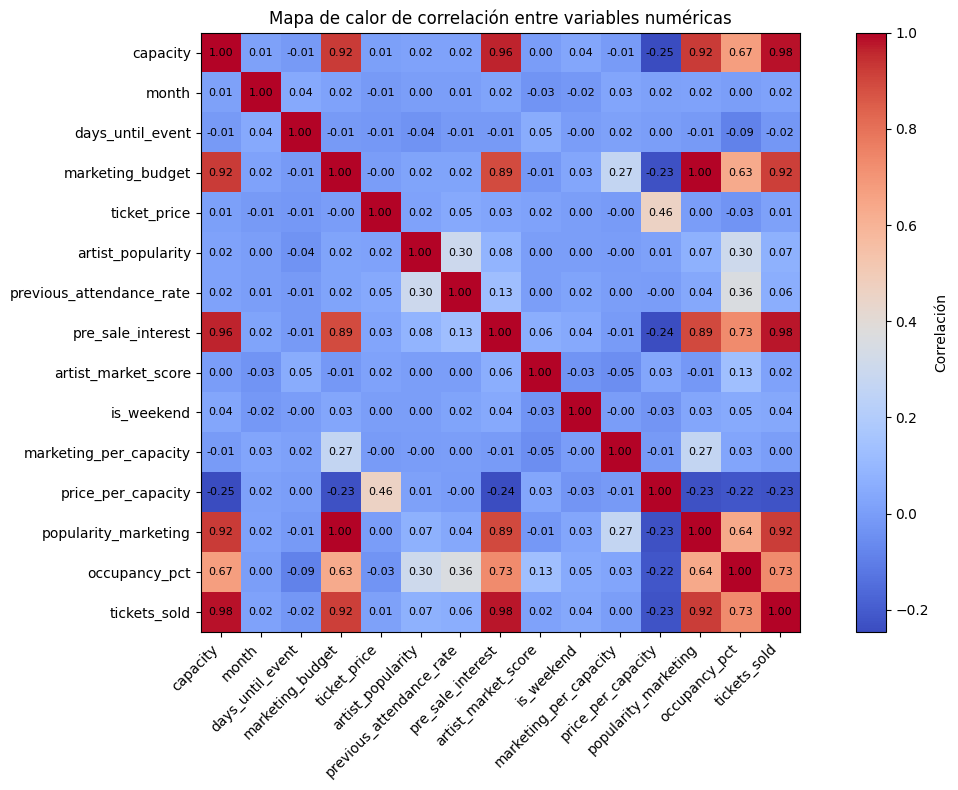

In [10]:
corr = df[numeric_columns].corr()

plt.figure(figsize=(12, 8))
plt.imshow(corr, cmap="coolwarm", interpolation="nearest")
plt.colorbar(label="Correlación")

plt.xticks(range(len(corr.columns)), corr.columns, rotation=45, ha="right")
plt.yticks(range(len(corr.columns)), corr.columns)

for i in range(len(corr.columns)):
    for j in range(len(corr.columns)):
        plt.text(
            j,
            i,
            f"{corr.iloc[i, j]:.2f}",
            ha="center",
            va="center",
            color="black",
            fontsize=8,
        )

plt.title("Mapa de calor de correlación entre variables numéricas")
plt.tight_layout()
plt.show()

## 11. Análisis de variables categóricas

Se revisan las variables categóricas principales del dataset: artista, género, ciudad, país, recinto y día del evento.


In [11]:
categorical_columns = [
    "artist",
    "genre",
    "city",
    "country",
    "venue_type",
    "event_day",
    "demand_class",
]

for col in categorical_columns:
    print(f"\nVariable: {col}")
    print(df[col].value_counts().head(15))


Variable: artist
artist
Martin Garrix      47
David Guetta       44
Kendrick Lamar     42
Stray Kids         41
TWICE              40
Banda MS           39
Dua Lipa           39
Imagine Dragons    38
aespa              38
The Weeknd         38
Girl Ultra         38
Siddhartha         37
Clairo             36
Arctic Monkeys     36
BTS                36
Name: count, dtype: int64

Variable: genre
genre
kpop                 215
pop                  213
indie                146
rap                  130
electronica          121
rock                 102
banda                 70
regional_mexicano     67
reggaeton             66
norteno               35
corridos              35
Name: count, dtype: int64

Variable: city
city
Bogota         148
Leon           145
Madrid         140
CDMX           139
Guadalajara    134
Los Angeles    131
Monterrey      131
Queretaro      123
Seul           109
Name: count, dtype: int64

Variable: country
country
Mexico            672
Colombia          148
España

## 12. Distribución por país

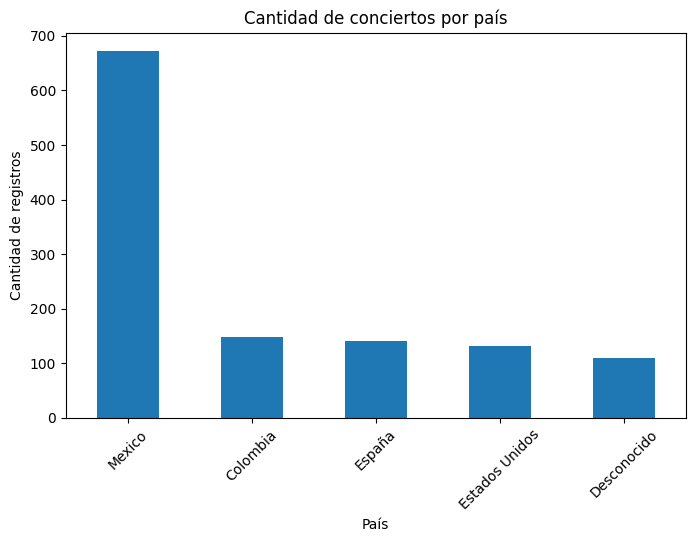

In [12]:
df["country"].value_counts().plot(kind="bar", figsize=(8, 5))

plt.title("Cantidad de conciertos por país")
plt.xlabel("País")
plt.ylabel("Cantidad de registros")
plt.xticks(rotation=45)
plt.show()

## 13. Distribución por género musical

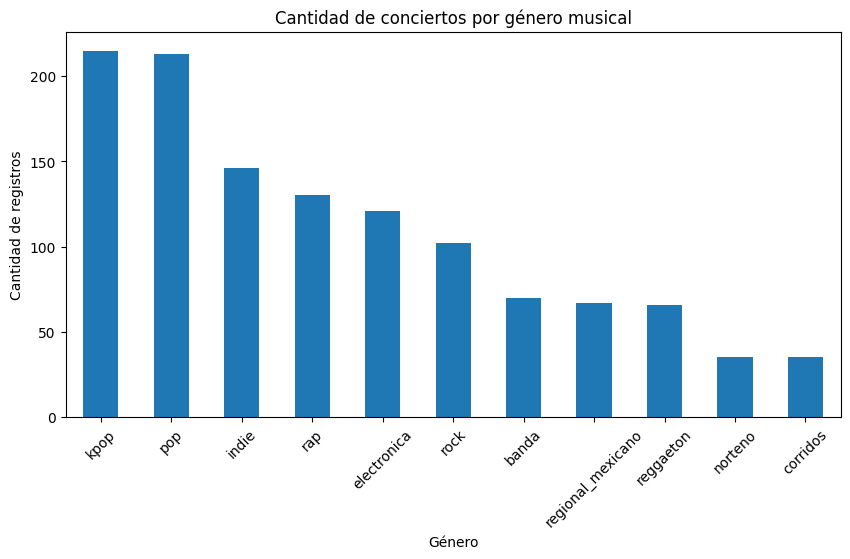

In [13]:
df["genre"].value_counts().plot(kind="bar", figsize=(10, 5))

plt.title("Cantidad de conciertos por género musical")
plt.xlabel("Género")
plt.ylabel("Cantidad de registros")
plt.xticks(rotation=45)
plt.show()

## 14. Demanda por país

Se analiza cómo se distribuyen las clases de demanda por país.  
Esto permite observar si existen diferencias entre mercados nacionales e internacionales.


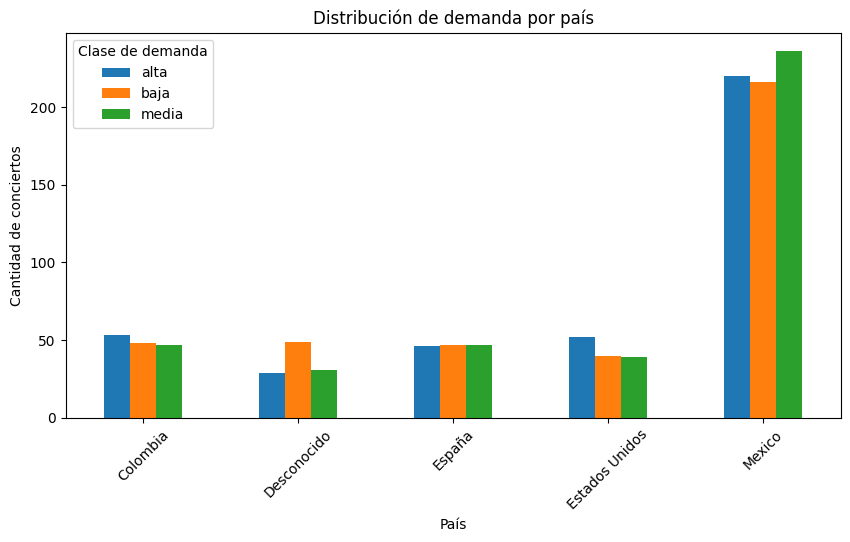

In [14]:
pd.crosstab(df["country"], df["demand_class"]).plot(kind="bar", figsize=(10, 5))

plt.title("Distribución de demanda por país")
plt.xlabel("País")
plt.ylabel("Cantidad de conciertos")
plt.xticks(rotation=45)
plt.legend(title="Clase de demanda")
plt.show()

## 15. Demanda por tipo de recinto

El tipo de recinto puede influir en la demanda esperada, ya que no es lo mismo un club, un teatro, una arena o un estadio.


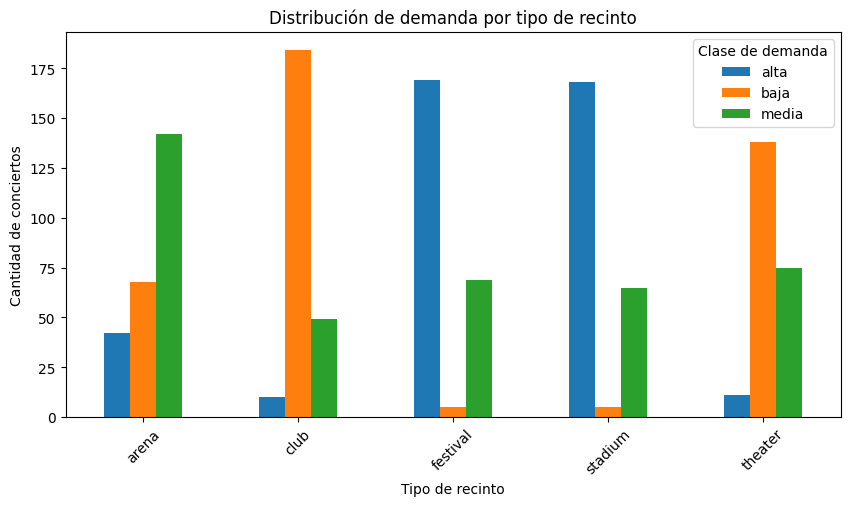

In [15]:
pd.crosstab(df["venue_type"], df["demand_class"]).plot(kind="bar", figsize=(10, 5))

plt.title("Distribución de demanda por tipo de recinto")
plt.xlabel("Tipo de recinto")
plt.ylabel("Cantidad de conciertos")
plt.xticks(rotation=45)
plt.legend(title="Clase de demanda")
plt.show()

## 16. Demanda por día del evento

Se analiza la relación entre el día del evento y la demanda.  
Los conciertos en viernes o sábado pueden tener mayor probabilidad de asistencia.


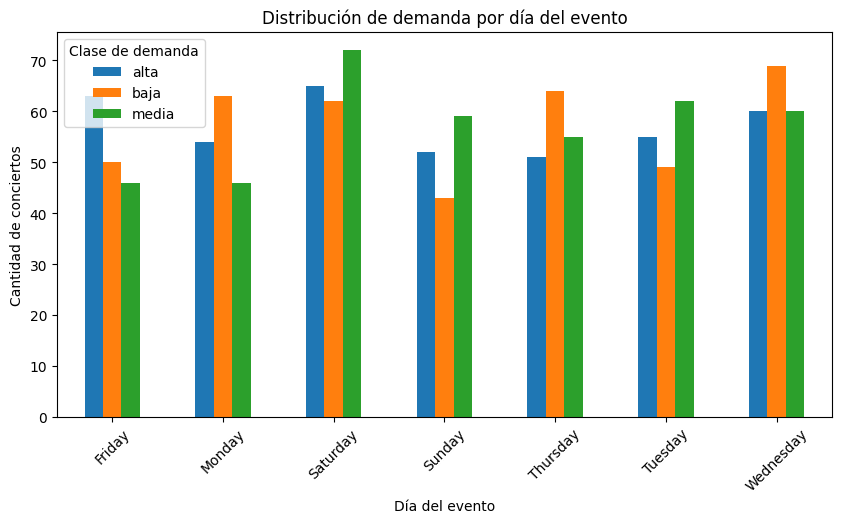

In [16]:
pd.crosstab(df["event_day"], df["demand_class"]).plot(kind="bar", figsize=(10, 5))

plt.title("Distribución de demanda por día del evento")
plt.xlabel("Día del evento")
plt.ylabel("Cantidad de conciertos")
plt.xticks(rotation=45)
plt.legend(title="Clase de demanda")
plt.show()

## 17. Promedio de ocupación por clase

Aunque `occupancy_pct` no se usa para entrenar, permite validar que la clase de demanda tenga sentido.

Se espera que:

- demanda baja tenga menor ocupación;
- demanda media tenga ocupación intermedia;
- demanda alta tenga mayor ocupación.


demand_class
alta     0.881000
baja     0.402550
media    0.666325
Name: occupancy_pct, dtype: float64


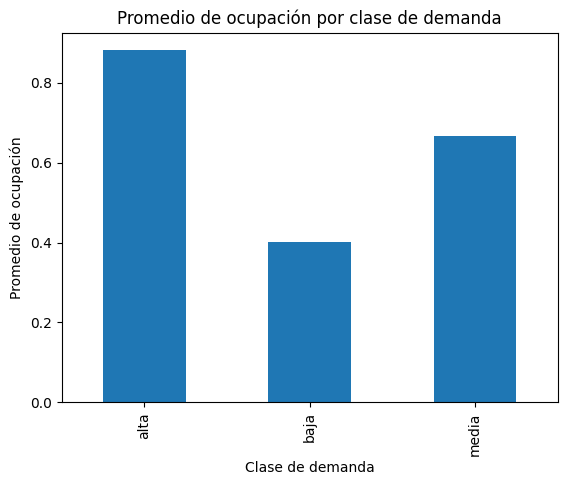

In [17]:
occupancy_by_class = df.groupby("demand_class")["occupancy_pct"].mean()

print(occupancy_by_class)

occupancy_by_class.plot(kind="bar")

plt.title("Promedio de ocupación por clase de demanda")
plt.xlabel("Clase de demanda")
plt.ylabel("Promedio de ocupación")
plt.show()

## 18. Análisis de variables históricas por artista

Se revisan las nuevas variables históricas simuladas, especialmente para artistas como BTS y Peso Pluma.


,previous_attendance_rate,pre_sale_interest,artist_popularity,occupancy_pct
artist,,,,
BTS,0.95,21577.722222,99.0,0.857222
The Weeknd,0.90,22218.052632,96.0,0.811842
Ariana Grande,0.88,14707.818182,95.0,0.824242
Drake,0.86,16364.107143,94.0,0.772857
TWICE,0.84,16319.100000,92.0,0.783250
David Guetta,0.82,20656.818182,93.0,0.763409
Grupo Firme,0.78,16415.193548,90.0,0.685806
Los Tigres del Norte,0.74,11689.457143,92.0,0.604286
Arctic Monkeys,0.70,14929.250000,92.0,0.625000


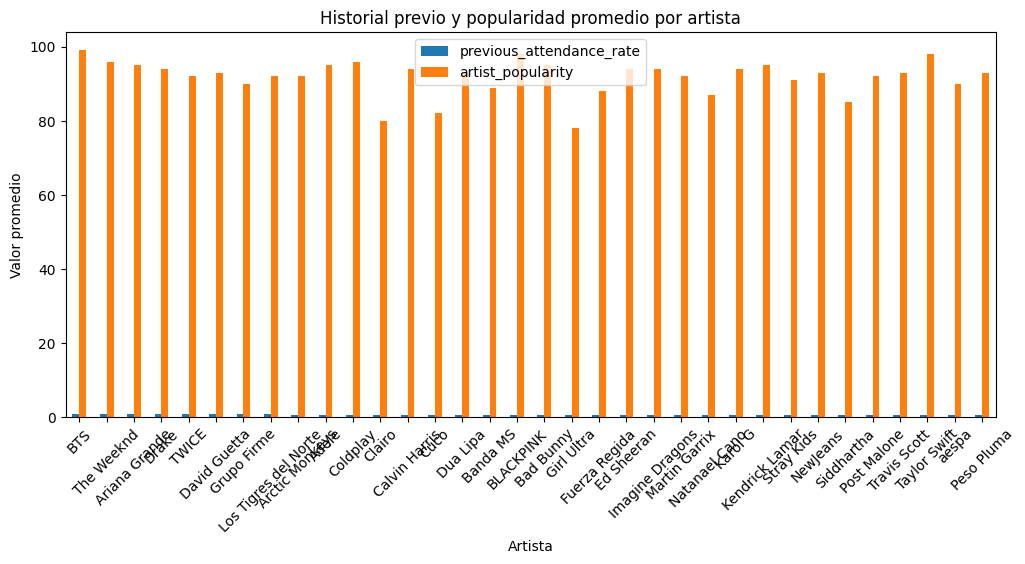

In [18]:
artist_summary = df.groupby("artist")[
    [
        "previous_attendance_rate",
        "pre_sale_interest",
        "artist_popularity",
        "occupancy_pct",
    ]
].mean().sort_values(by="previous_attendance_rate", ascending=False)

display(artist_summary)

artist_summary[["previous_attendance_rate", "artist_popularity"]].plot(kind="bar", figsize=(12, 5))

plt.title("Historial previo y popularidad promedio por artista")
plt.xlabel("Artista")
plt.ylabel("Valor promedio")
plt.xticks(rotation=45)
plt.show()

## 19. Revisión de posibles valores atípicos

Se revisan variables numéricas que podrían tener valores extremos, como precio, marketing, capacidad e interés de preventa.


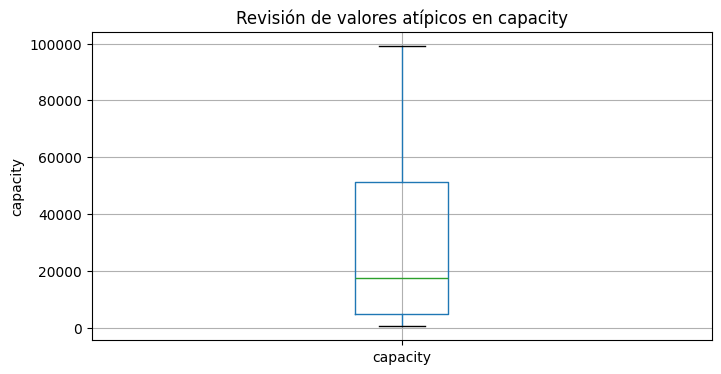

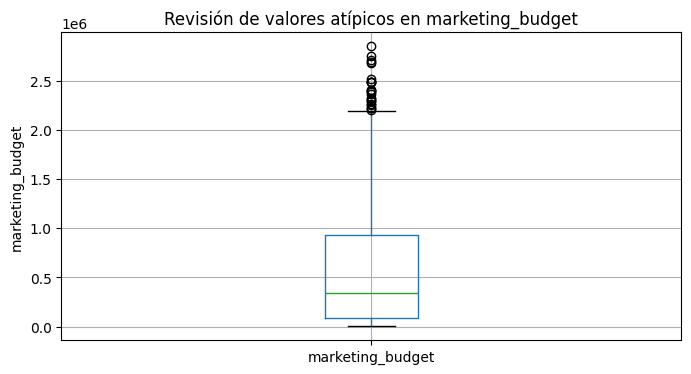

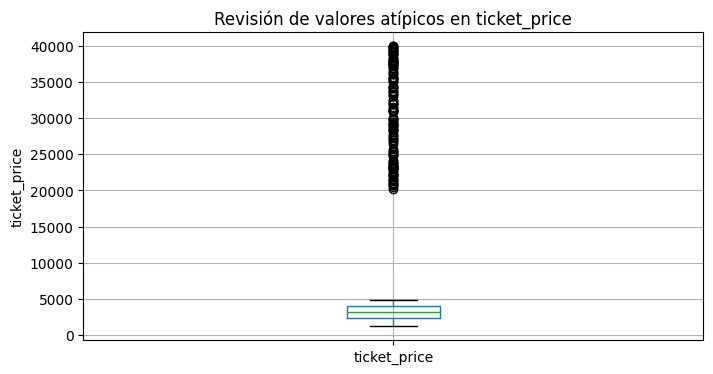

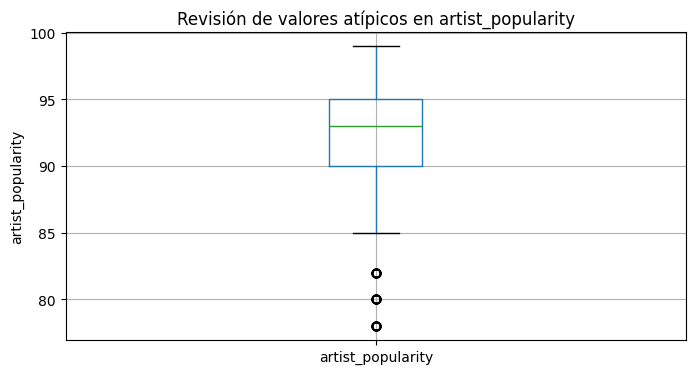

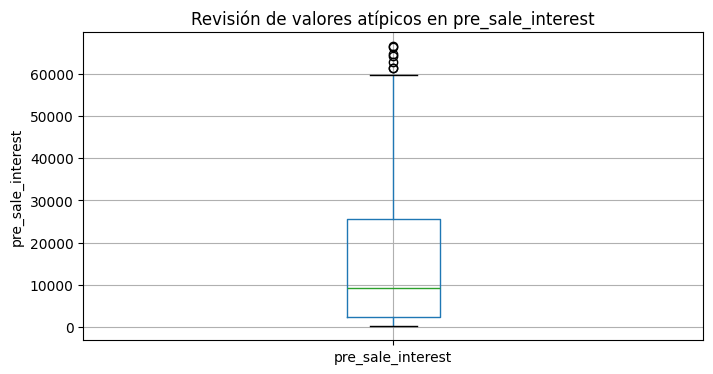

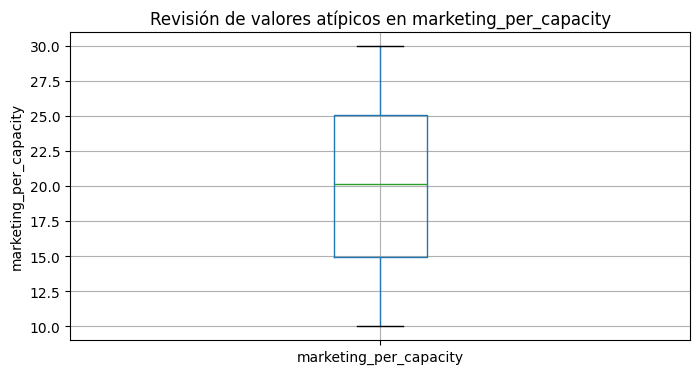

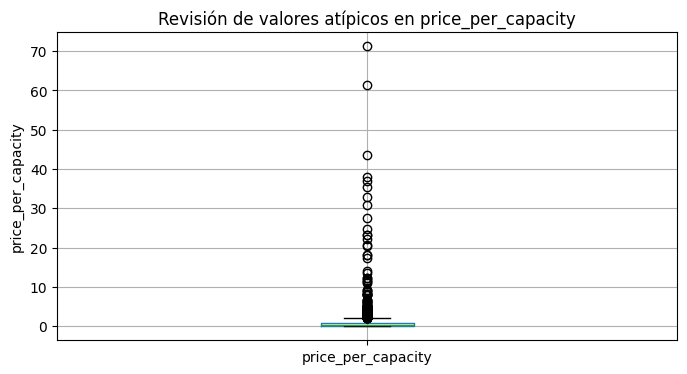

In [20]:
outlier_columns = [
    "capacity",
    "marketing_budget",
    "ticket_price",
    "artist_popularity",
    "pre_sale_interest",
    "marketing_per_capacity",
    "price_per_capacity",
]

for col in outlier_columns:
    plt.figure(figsize=(8, 4))
    df.boxplot(column=col)
    plt.title(f"Revisión de valores atípicos en {col}")
    plt.ylabel(col)
    plt.show()

## 20. Variables recomendadas para el entrenamiento

A partir del análisis, las variables recomendadas para entrenamiento son las disponibles antes del concierto:

- artista;
- género;
- ciudad;
- país;
- tipo de recinto;
- capacidad;
- mes;
- día del evento;
- días restantes;
- presupuesto de marketing;
- precio;
- popularidad del artista;
- historial previo;
- interés de preventa;
- score de mercado;
- variables derivadas de precio y marketing.

No deben utilizarse:

- `occupancy_pct`;
- `tickets_sold`.

Estas dos columnas representan resultados posteriores al evento.


In [21]:
features_recommended = [
    "artist",
    "genre",
    "city",
    "country",
    "venue_type",
    "capacity",
    "month",
    "event_day",
    "days_until_event",
    "marketing_budget",
    "ticket_price",
    "artist_popularity",
    "previous_attendance_rate",
    "pre_sale_interest",
    "artist_market_score",
    "is_weekend",
    "marketing_per_capacity",
    "price_per_capacity",
    "popularity_marketing",
]

target = "demand_class"

print("Variables recomendadas:")
print(features_recommended)

print("\nVariable objetivo:")
print(target)

X_preview = df[features_recommended]
y_preview = df[target]

print("\nTamaño de X:", X_preview.shape)
print("Tamaño de y:", y_preview.shape)

Variables recomendadas:
['artist', 'genre', 'city', 'country', 'venue_type', 'capacity', 'month', 'event_day', 'days_until_event', 'marketing_budget', 'ticket_price', 'artist_popularity', 'previous_attendance_rate', 'pre_sale_interest', 'artist_market_score', 'is_weekend', 'marketing_per_capacity', 'price_per_capacity', 'popularity_marketing']

Variable objetivo:
demand_class

Tamaño de X: (1200, 19)
Tamaño de y: (1200,)


## 21. Conclusiones

El análisis exploratorio permitió validar que el dataset actualizado de ConcertDemandAI contiene variables suficientes para continuar con la etapa de entrenamiento.

El dataset incluye información básica del concierto, como artista, género, ciudad, país, tipo de recinto, capacidad, fecha, precio, presupuesto de marketing y popularidad del artista. Además, se incorporaron nuevas variables simuladas de historial previo e interés de preventa, como `previous_attendance_rate`, `pre_sale_interest` y `artist_market_score`.

Estas nuevas variables permiten representar señales disponibles antes del evento y pueden ayudar a mejorar la capacidad del modelo para distinguir entre demanda baja, media y alta.

También se confirmó que `occupancy_pct` y `tickets_sold` deben mantenerse únicamente para análisis exploratorio, ya que representan información posterior al evento y no deben utilizarse como variables de entrada del modelo.

En general, el dataset queda preparado para la fase de entrenamiento, la cual debe realizarse en un notebook separado o en el archivo `model/train.py`.


## 22. Trabajo futuro

Como trabajo futuro, se recomienda:

- validar el modelo con datos reales de conciertos;
- incorporar métricas reales de preventa;
- agregar datos de plataformas musicales o redes sociales;
- comparar diferentes modelos de clasificación;
- integrar el modelo entrenado en una aplicación Streamlit;
- monitorear el desempeño del modelo si se usa en un escenario real.
